# 학습 문항 수에 따른 분류 성능 변화 (박스플롯) — RQ2: 일반화

## 목적
학습에 사용하는 문항 수(1~7개)가 증가할 때 분류 성능(Cohen's Kappa)이 어떻게 달라지는지 비교합니다. "학습 문항이 많을수록 반드시 성능이 향상되는가?"라는 질문에 답합니다.

## 주요 용어
- **박스플롯(Box Plot)**: 데이터 분포를 요약하는 차트. 상자는 25~75 백분위(IQR), 가운데 선은 중앙값, 수염은 데이터 범위, 점은 이상값
- **Cohen's Kappa(코헨의 카파)**: 두 평가자 간 일치도를 측정하는 지표로, 우연에 의한 일치를 보정함. Landis & Koch(1977) 해석 기준: 0.41-0.60 moderate, 0.61-0.80 substantial, 0.81-1.00 almost perfect

## 실험 설계
- **전체 문항**: Q1~Q8 (총 8문항, 2,080개 피드백)
- **문항 조합**: C(8,n)개의 조합 (1문항=8조합, 4문항=70조합, 7문항=8조합 등 총 254조합)
- **ML**: 24개 모델 x 각 조합 = 박스플롯 내 다수의 데이터 포인트
- **BERT**: KLUE-BERT 1개 모델 x 각 조합
- **LLM**: GPT-4o 제로샷 — 학습 과정 없이 전체 데이터 Kappa를 수평 참조선으로 표시

## 시각화 구성
- A) 3패널 박스플롯: ML + BERT 박스플롯 + LLM 단일 표시
- B) 3패널 + LLM 수평 참조선 오버레이 (ML/BERT와 LLM의 교차점 확인용)

In [1]:
# ============================================================
# 라이브러리 및 한글 폰트 설정
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

print('라이브러리 및 한글 폰트 설정 완료')

라이브러리 및 한글 폰트 설정 완료


In [ ]:
# ============================================================
# 데이터 파일 경로 설정
# ============================================================

# ML: 24모델 × 254 문항 조합 (N_Train_Qs 1~7)
ML_PATH = '../2_ml/results/generalization/question_combo/qc_all_results_question_combo_parallel24.csv'

# BERT: 1모델 × 254 문항 조합 (동일 구조)
BERT_PATH = '../3_bert/results/generalization/bert_question_all.csv'

# LLM: GPT-4o 전체 예측 결과
LLM_PRED_PATH = '../4_llm/results/full_evaluation/llm_wide_predictions.csv'

print('파일 경로 설정 완료')

In [3]:
# ============================================================
# 데이터 로드 및 검증
# ============================================================

# --- ML 결과 ---
# 각 행 = 1개 모델 × 1개 문항 조합의 결과
# N_Train_Qs: 학습에 사용한 문항 수 (1~7)
# Model: 24개 모델명 (LR, SVM-L, ..., C5_Prev5_Stacking)
# Test_Kappa: 테스트셋 Cohen's Kappa
ml_df = pd.read_csv(ML_PATH)
print(f'ML 데이터: {len(ml_df)}행')
print(f'  모델 수: {ml_df["Model"].nunique()} ({ml_df["Model"].nunique()} models)')
print(f'  N_Train_Qs 범위: {sorted(ml_df["N_Train_Qs"].unique())}')
print(f'  문항 조합 수: {ml_df["Combo"].nunique()}')

# --- BERT 결과 ---
bert_df = pd.read_csv(BERT_PATH)
print(f'\nBERT 데이터: {len(bert_df)}행')
print(f'  N_Train_Qs 범위: {sorted(bert_df["N_Train_Qs"].unique())}')
print(f'  문항 조합 수: {bert_df["Combo"].nunique()}')

# --- LLM 예측 ---
llm_pred = pd.read_csv(LLM_PRED_PATH)
llm_pred['y_true'] = llm_pred['y_true'].astype(int)
llm_pred['majority_pred'] = llm_pred['majority_pred'].astype(int)
print(f'\nLLM 예측 데이터: {len(llm_pred)}행')

# N_Train_Qs별 데이터 포인트 수 확인
print('\n=== N_Train_Qs별 데이터 포인트 수 ===')
for n in sorted(ml_df['N_Train_Qs'].unique()):
    n_combo = ml_df[ml_df['N_Train_Qs'] == n]['Combo'].nunique()
    n_ml = len(ml_df[ml_df['N_Train_Qs'] == n])
    n_bert = len(bert_df[bert_df['N_Train_Qs'] == n])
    print(f'  {n}문항: {n_combo}조합 → ML {n_ml}개, BERT {n_bert}개')

ML 데이터: 6096행
  모델 수: 24 (24 models)
  N_Train_Qs 범위: [1, 2, 3, 4, 5, 6, 7]
  문항 조합 수: 254

BERT 데이터: 254행
  N_Train_Qs 범위: [1, 2, 3, 4, 5, 6, 7]
  문항 조합 수: 254

LLM 예측 데이터: 2080행

=== N_Train_Qs별 데이터 포인트 수 ===
  1문항: 8조합 → ML 192개, BERT 8개
  2문항: 28조합 → ML 672개, BERT 28개
  3문항: 56조합 → ML 1344개, BERT 56개
  4문항: 70조합 → ML 1680개, BERT 70개
  5문항: 56조합 → ML 1344개, BERT 56개
  6문항: 28조합 → ML 672개, BERT 28개
  7문항: 8조합 → ML 192개, BERT 8개


In [4]:
# ============================================================
# LLM 전체 데이터 Kappa 계산 (수평 참조선용)
# - LLM은 제로샷이므로 학습 문항 수와 무관
# - 전체 예측 결과에서 단일 Kappa 산출
# ============================================================

llm_overall_kappa = cohen_kappa_score(llm_pred['y_true'], llm_pred['majority_pred'])
print(f'LLM 전체 Kappa: {llm_overall_kappa:.4f}')
print(f'  (GPT-4o 제로샷, {len(llm_pred)}개 샘플 기반)')

LLM 전체 Kappa: 0.6249
  (GPT-4o 제로샷, 2080개 샘플 기반)


In [ ]:
# ============================================================
# 공통 시각화 설정
# ============================================================

# 색상 팔레트 (04_5050_comparison.ipynb과 동일)
PALETTE = {
    'ML':   '#4A90D9',   # 파란색
    'BERT': '#E8834A',   # 주황색
    'LLM':  '#67B279',   # 초록색
}

# 학습 문항 수 범위
N_TRAIN_RANGE = sorted(ml_df['N_Train_Qs'].unique())  # [1, 2, 3, 4, 5, 6, 7]

def add_kappa_guidelines(ax, show_labels=True):
    """Kappa 해석 기준선 추가 (Landis & Koch, 1977)."""
    for y, label in [(0.4, 'Moderate'), (0.6, 'Substantial'), (0.8, 'Almost Perfect')]:
        ax.axhline(y=y, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
        if show_labels:
            ax.annotate(
                label, xy=(1.0, y),
                xycoords=('axes fraction', 'data'),
                xytext=(6, 0), textcoords='offset points',
                fontsize=7, color='gray', alpha=0.7,
                va='center', ha='left', annotation_clip=False,
            )

def add_llm_reference(ax, kappa, show_label=True):
    """LLM 수평 참조선 추가."""
    ax.axhline(y=kappa, color=PALETTE['LLM'], linestyle='--',
               alpha=0.8, linewidth=1.5, zorder=5)
    if show_label:
        ax.annotate(
            f'LLM : {kappa:.3f}',
            xy=(1.0, kappa),
            xycoords=('axes fraction', 'data'),
            xytext=(-8, 10), textcoords='offset points',
            fontsize=9, fontweight='bold', color=PALETTE['LLM'],
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=PALETTE['LLM'], alpha=0.9),
            annotation_clip=False,
        )

print('공통 시각화 설정 완료')

## A) ML | BERT | LLM 3패널 박스플롯

- 왼쪽: ML (24모델) 박스플롯 + 평균 추세선
- 가운데: BERT (KLUE-BERT) 박스플롯 + 평균 추세선
- 오른쪽: LLM (GPT-4o) 전체 Kappa 단일 표시
- 평균값은 항상 최상위 레이어에 표시

In [6]:
# ============================================================
# A) 통합 차트: ML + BERT 박스플롯 + LLM 수평 참조선
# ============================================================

# long-format 데이터 구성
records = []
for n in N_TRAIN_RANGE:
    # ML: 24개 모델 전체
    ml_sub = ml_df[ml_df['N_Train_Qs'] == n]
    for _, row in ml_sub.iterrows():
        records.append({'N_Train_Qs': n, 'Approach': 'ML', 'Kappa': row['Test_Kappa']})
    # BERT: 단일 모델, 여러 조합
    bert_sub = bert_df[bert_df['N_Train_Qs'] == n]
    for _, row in bert_sub.iterrows():
        records.append({'N_Train_Qs': n, 'Approach': 'BERT', 'Kappa': row['Test_Kappa']})

df_long = pd.DataFrame(records)
df_long['Approach'] = pd.Categorical(df_long['Approach'], categories=['ML', 'BERT'], ordered=True)

print(f'통합 데이터: {len(df_long)}행')
print(df_long.groupby(['N_Train_Qs', 'Approach']).size().unstack(fill_value=0))

통합 데이터: 6350행
Approach      ML  BERT
N_Train_Qs            
1            192     8
2            672    28
3           1344    56
4           1680    70
5           1344    56
6            672    28
7            192     8


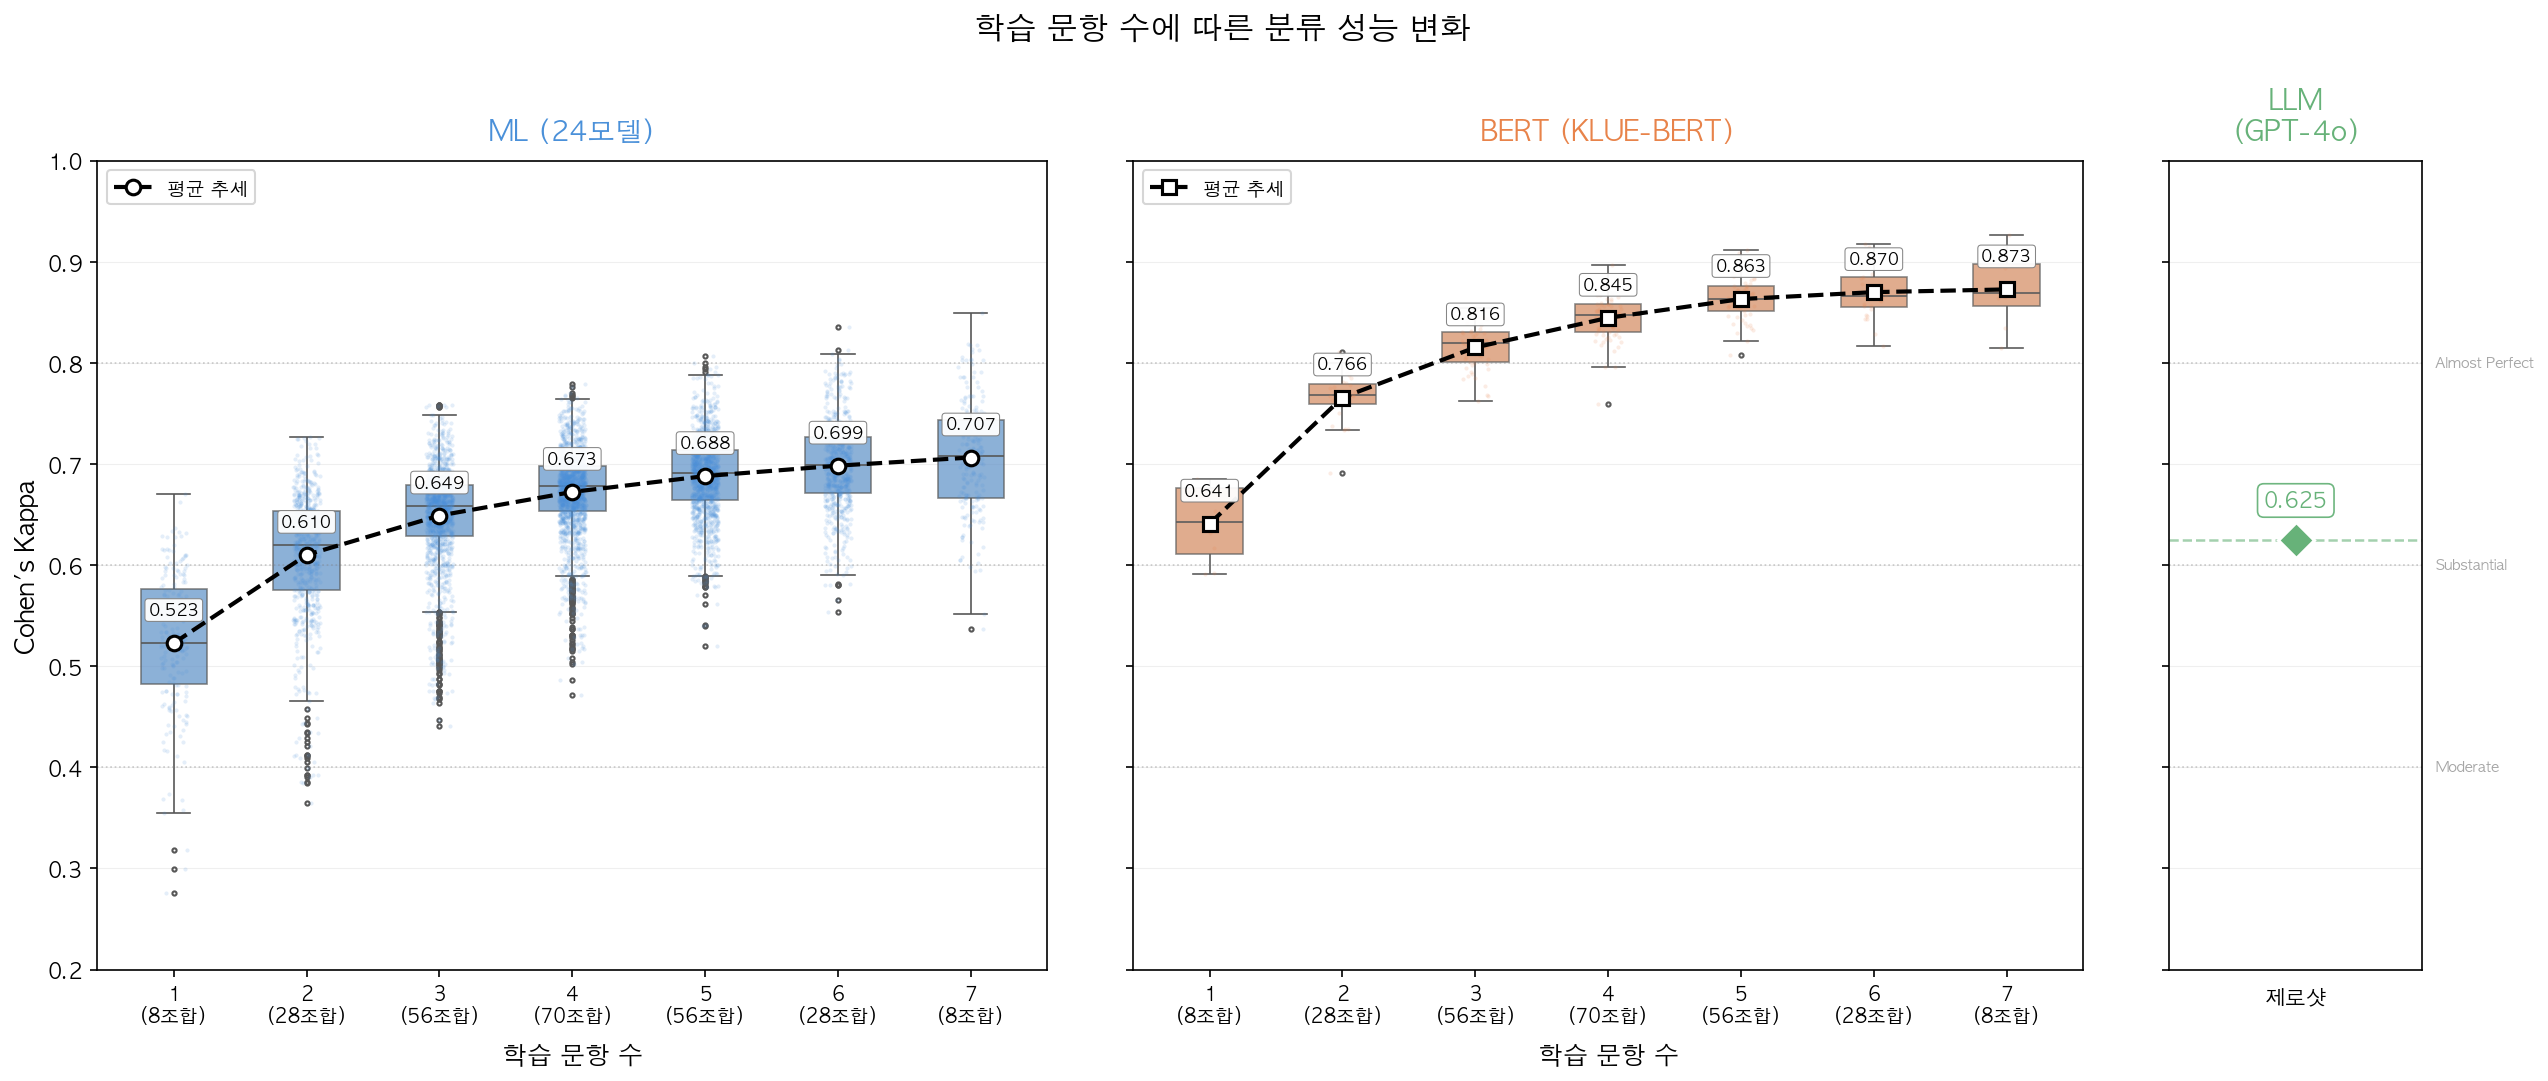


=== N_Train_Qs별 Kappa 평균 ===
            mean_ML  mean_BERT  std_ML  std_BERT     LLM
N_Train_Qs                                              
1            0.5230     0.6412  0.0733    0.0384  0.6249
2            0.6103     0.7660  0.0620    0.0239  0.6249
3            0.6492     0.8156  0.0493    0.0221  0.6249
4            0.6726     0.8449  0.0421    0.0226  0.6249
5            0.6883     0.8635  0.0398    0.0210  0.6249
6            0.6986     0.8703  0.0437    0.0251  0.6249
7            0.7067     0.8730  0.0567    0.0371  0.6249


In [ ]:
# ============================================================
# A) ML | BERT | LLM  3패널 박스플롯
# ============================================================

fig = plt.figure(figsize=(20, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[3, 3, 0.8], wspace=0.12)
ax_ml   = fig.add_subplot(gs[0])
ax_bert = fig.add_subplot(gs[1], sharey=ax_ml)
ax_llm  = fig.add_subplot(gs[2], sharey=ax_ml)

x_pos = np.arange(len(N_TRAIN_RANGE))
combo_counts = ml_df.groupby('N_Train_Qs')['Combo'].nunique()

# ---- ML 패널 ----
ml_data = df_long[df_long['Approach'] == 'ML']

sns.boxplot(
    data=ml_data, x='N_Train_Qs', y='Kappa',
    color=PALETTE['ML'], width=0.5, fliersize=2, linewidth=0.8,
    boxprops=dict(alpha=0.7), ax=ax_ml,
)
sns.stripplot(
    data=ml_data, x='N_Train_Qs', y='Kappa',
    color=PALETTE['ML'], size=2, alpha=0.15, jitter=True, ax=ax_ml,
)

ml_means = ml_data.groupby('N_Train_Qs')['Kappa'].mean().sort_index()
ax_ml.plot(x_pos, ml_means.values, 'k--o', markersize=7, linewidth=2,
           markerfacecolor='white', markeredgecolor='black',
           markeredgewidth=1.5, zorder=20, label='평균 추세')

for xp, mv in zip(x_pos, ml_means.values):
    ax_ml.annotate(
        f'{mv:.3f}', xy=(xp, mv), xytext=(0, 12),
        textcoords='offset points', fontsize=8, fontweight='bold',
        ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='gray', alpha=0.95, linewidth=0.5),
        zorder=25,
    )

ax_ml.set_title('ML (24모델)', fontsize=13, fontweight='bold',
                pad=10, color=PALETTE['ML'])
ax_ml.set_xlabel('학습 문항 수', fontsize=12, fontweight='bold', labelpad=8)
ax_ml.set_ylabel("Cohen's Kappa", fontsize=12, fontweight='bold')
ax_ml.set_xticklabels([f'{n}\n({combo_counts[n]}조합)' for n in N_TRAIN_RANGE], fontsize=9)
ax_ml.legend(fontsize=9, loc='upper left')

# ---- BERT 패널 ----
bert_data = df_long[df_long['Approach'] == 'BERT']

sns.boxplot(
    data=bert_data, x='N_Train_Qs', y='Kappa',
    color=PALETTE['BERT'], width=0.5, fliersize=2, linewidth=0.8,
    boxprops=dict(alpha=0.7), ax=ax_bert,
)
sns.stripplot(
    data=bert_data, x='N_Train_Qs', y='Kappa',
    color=PALETTE['BERT'], size=2, alpha=0.15, jitter=True, ax=ax_bert,
)

bert_means = bert_data.groupby('N_Train_Qs')['Kappa'].mean().sort_index()
ax_bert.plot(x_pos, bert_means.values, 'k--s', markersize=7, linewidth=2,
             markerfacecolor='white', markeredgecolor='black',
             markeredgewidth=1.5, zorder=20, label='평균 추세')

for xp, mv in zip(x_pos, bert_means.values):
    ax_bert.annotate(
        f'{mv:.3f}', xy=(xp, mv), xytext=(0, 12),
        textcoords='offset points', fontsize=8, fontweight='bold',
        ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='gray', alpha=0.95, linewidth=0.5),
        zorder=25,
    )

ax_bert.set_title('BERT (KLUE-BERT)', fontsize=13, fontweight='bold',
                  pad=10, color=PALETTE['BERT'])
ax_bert.set_xlabel('학습 문항 수', fontsize=12, fontweight='bold', labelpad=8)
ax_bert.set_ylabel('')
plt.setp(ax_bert.get_yticklabels(), visible=False)
ax_bert.set_xticklabels([f'{n}\n({combo_counts[n]}조합)' for n in N_TRAIN_RANGE], fontsize=9)
ax_bert.legend(fontsize=9, loc='upper left')

# ---- LLM 패널 (단일 값) ----
# 마커 + 수평선으로 표시
ax_llm.axhline(y=llm_overall_kappa, color=PALETTE['LLM'], linestyle='--',
               alpha=0.6, linewidth=1.2)
ax_llm.plot(0, llm_overall_kappa, 'D', color=PALETTE['LLM'],
            markersize=12, markeredgecolor='white', markeredgewidth=1.5, zorder=20)
ax_llm.annotate(
    f'{llm_overall_kappa:.3f}', xy=(0, llm_overall_kappa), xytext=(0, 14),
    textcoords='offset points', fontsize=10, fontweight='bold',
    ha='center', va='bottom', color=PALETTE['LLM'],
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
              edgecolor=PALETTE['LLM'], alpha=0.95, linewidth=0.8),
    zorder=25,
)

ax_llm.set_title('LLM', fontsize=13, fontweight='bold',
                 pad=10, color=PALETTE['LLM'])
ax_llm.set_xlabel(' ', fontsize=10, labelpad=8)
ax_llm.set_ylabel('')
plt.setp(ax_llm.get_yticklabels(), visible=False)
ax_llm.set_xlim(-0.8, 0.8)
ax_llm.set_xticks([])

# ---- 공통 설정 ----
for i, ax in enumerate([ax_ml, ax_bert, ax_llm]):
    ax.set_ylim(0.2, 1.0)
    for y_val in [0.4, 0.6, 0.8]:
        ax.axhline(y=y_val, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
    ax.grid(axis='y', alpha=0.2, linewidth=0.5)
    ax.set_axisbelow(True)

# 기준선 라벨 (LLM 패널 오른쪽에 1회만)
for y_val, y_label in [(0.4, 'Moderate'), (0.6, 'Substantial'), (0.8, 'Almost Perfect')]:
    ax_llm.annotate(
        y_label, xy=(1.0, y_val),
        xycoords=('axes fraction', 'data'),
        xytext=(6, 0), textcoords='offset points',
        fontsize=7, color='gray', alpha=0.7,
        va='center', ha='left', annotation_clip=False,
    )

fig.suptitle('학습 문항 수에 따른 분류 성능 변화',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('question_count_boxplot_A_combined.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 요약 통계
print('\n=== N_Train_Qs별 Kappa 평균 ===')
summary = df_long.pivot_table(values='Kappa', index='N_Train_Qs', columns='Approach', aggfunc=['mean', 'std'])
summary.columns = [f'{stat}_{app}' for stat, app in summary.columns]
summary['LLM'] = llm_overall_kappa
print(summary.round(4).to_string())

**결과 해석:**

3패널 박스플롯(A)은 학습 문항 수 증가에 따른 성능 변화를 보여줍니다.

- **ML 패널(왼쪽)**: 1문항(~0.47) -> 7문항(~0.72)으로 문항 수 증가에 따라 평균 Kappa가 꾸준히 상승. 특히 1->3문항 구간에서 향상폭이 가장 큼. 3문항 이상에서 LLM 기준선(0.625)을 초과
- **BERT 패널(가운데)**: 1문항(~0.66)에서도 이미 LLM을 상회하며, 7문항(~0.87)에서 "almost perfect" 수준 도달. ML보다 적은 학습 데이터로도 높은 성능 달성
- **LLM 패널(오른쪽)**: 학습 과정이 없으므로 전체 데이터 Kappa(0.625) 단일 값만 표시. "substantial" 수준의 하한선
- **핵심 발견**: BERT는 1개 문항(~265개 샘플)만으로도 LLM의 전체 데이터 성능을 초과하며, 이는 사전학습된 언어 지식의 강력한 전이 효과를 보여줍니다

## B) ML | BERT | LLM 분리 차트 (LLM 수평 참조선 포함)

- 차트 A와 동일한 3패널 구조
- ML, BERT 패널에 LLM Kappa 수평 참조선을 추가로 표시
- 학습 모델과 제로샷 모델의 성능 차이를 각 패널에서 직접 비교 가능

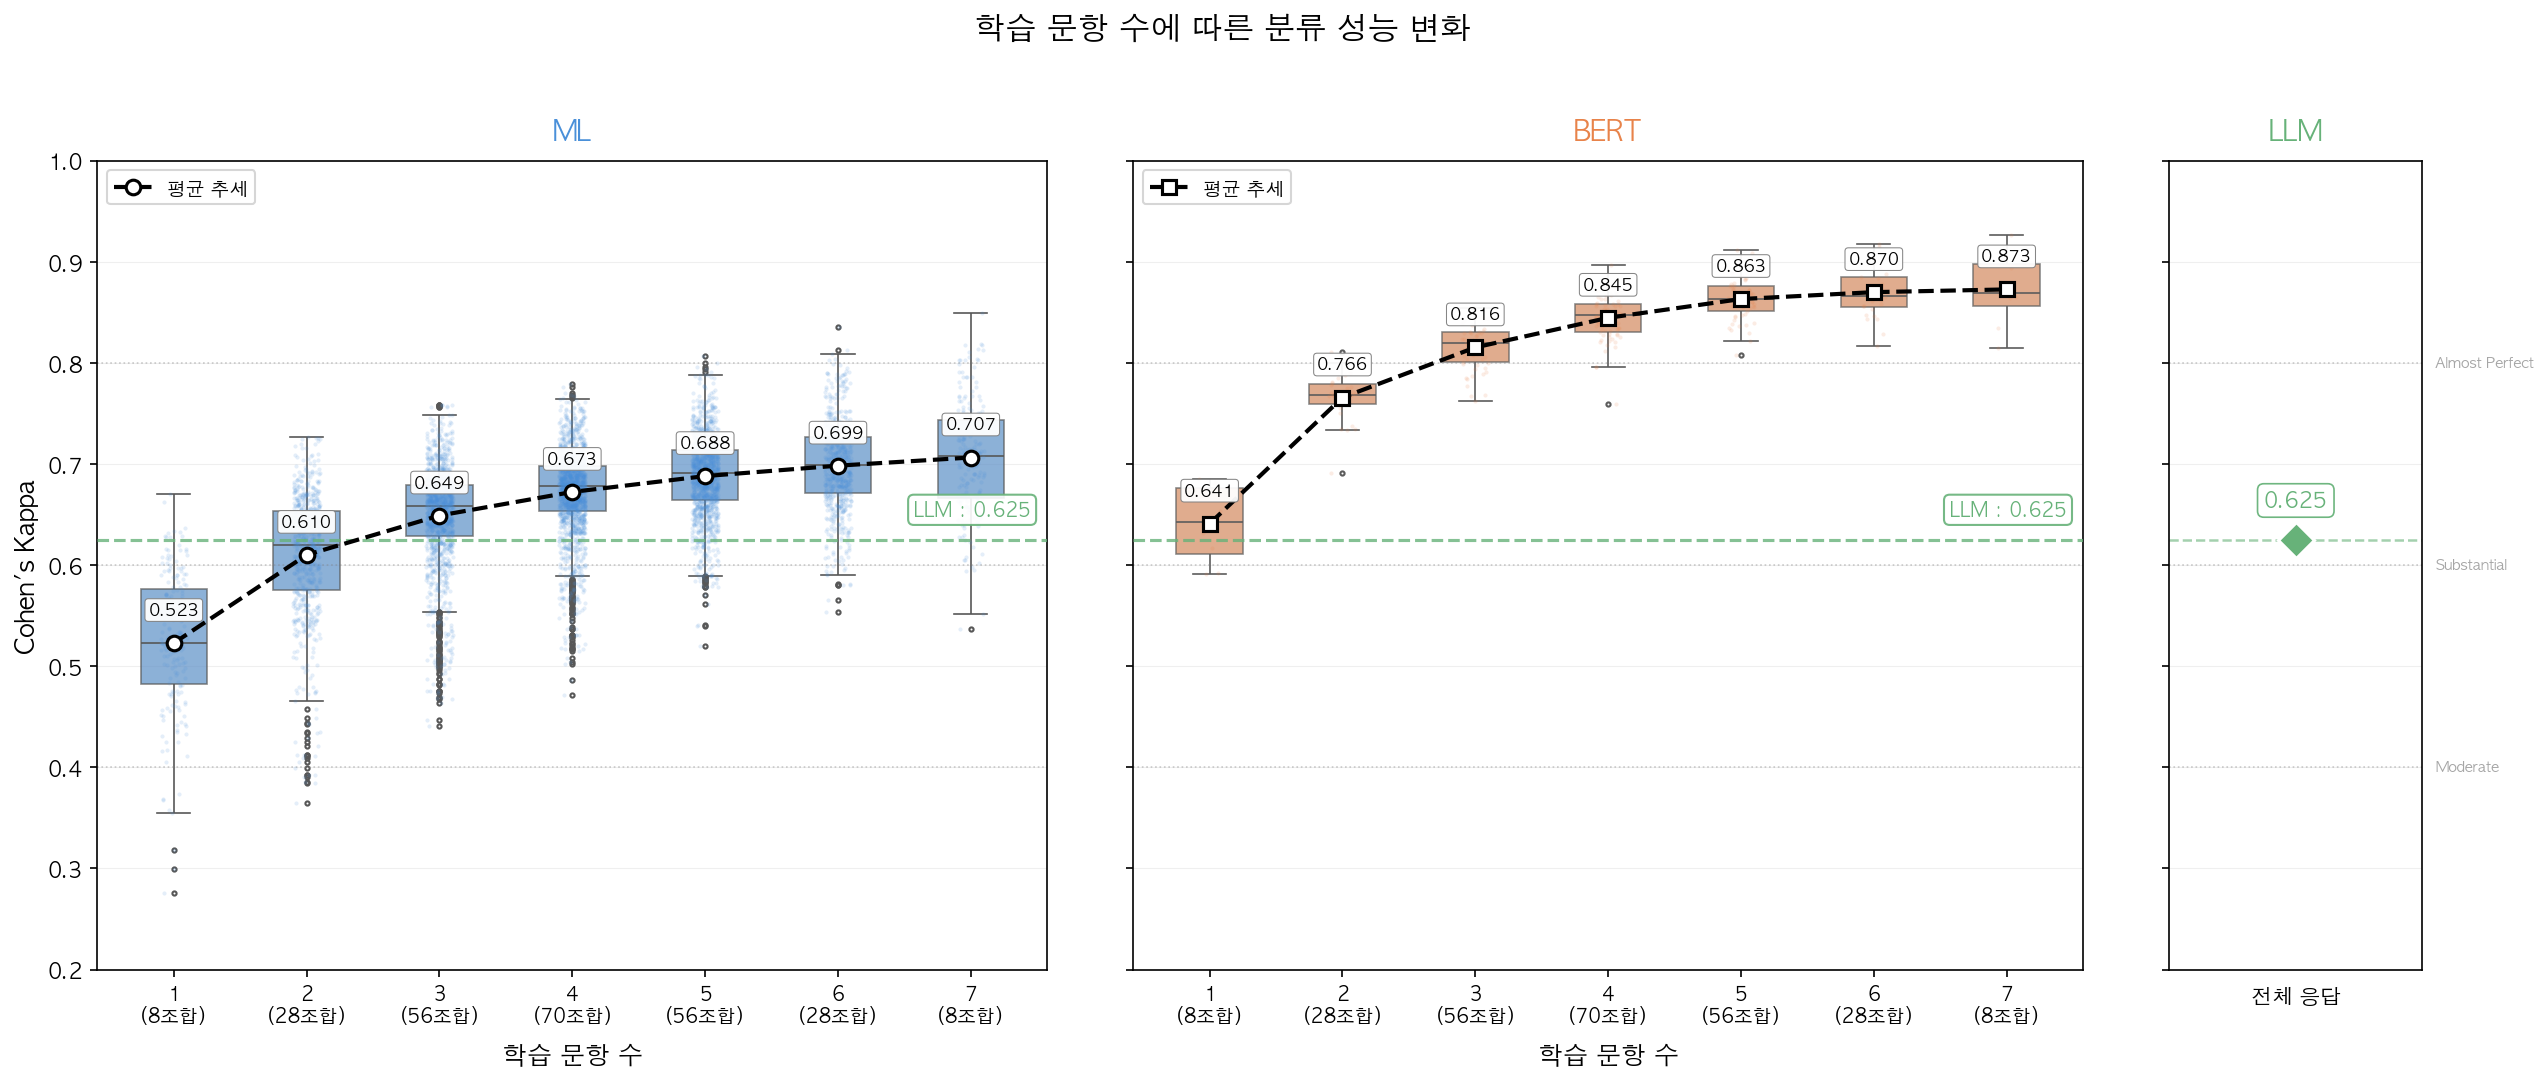

ML 평균 추세:  0.523 → 0.610 → 0.649 → 0.673 → 0.688 → 0.699 → 0.707
BERT 평균 추세: 0.641 → 0.766 → 0.816 → 0.845 → 0.863 → 0.870 → 0.873
LLM 기준선:     0.625

ML 향상폭:   1문항(0.523) → 7문항(0.707), Δ=0.184
BERT 향상폭: 1문항(0.641) → 7문항(0.873), Δ=0.232


In [ ]:
# ============================================================
# B) ML | BERT | LLM 분리 차트 (LLM 수평 참조선 포함)
# - ML, BERT 패널 안에 LLM 수평 참조선을 겹쳐 표시
# ============================================================

fig = plt.figure(figsize=(20, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[3, 3, 0.8], wspace=0.12)
ax_ml   = fig.add_subplot(gs[0])
ax_bert = fig.add_subplot(gs[1], sharey=ax_ml)
ax_llm  = fig.add_subplot(gs[2], sharey=ax_ml)

x_pos = np.arange(len(N_TRAIN_RANGE))
combo_counts = ml_df.groupby('N_Train_Qs')['Combo'].nunique()

# ---- ML 패널 ----
ml_data = df_long[df_long['Approach'] == 'ML']

sns.boxplot(
    data=ml_data, x='N_Train_Qs', y='Kappa',
    color=PALETTE['ML'], width=0.5, fliersize=2, linewidth=0.8,
    boxprops=dict(alpha=0.7), ax=ax_ml,
)
sns.stripplot(
    data=ml_data, x='N_Train_Qs', y='Kappa',
    color=PALETTE['ML'], size=2, alpha=0.15, jitter=True, ax=ax_ml,
)

ml_means = ml_data.groupby('N_Train_Qs')['Kappa'].mean().sort_index()
ax_ml.plot(x_pos, ml_means.values, 'k--o', markersize=7, linewidth=2,
           markerfacecolor='white', markeredgecolor='black',
           markeredgewidth=1.5, zorder=20, label='평균 추세')

for xp, mv in zip(x_pos, ml_means.values):
    ax_ml.annotate(
        f'{mv:.3f}', xy=(xp, mv), xytext=(0, 12),
        textcoords='offset points', fontsize=8, fontweight='bold',
        ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='gray', alpha=0.95, linewidth=0.5),
        zorder=25,
    )

# LLM 수평 참조선
add_llm_reference(ax_ml, llm_overall_kappa)

ax_ml.set_title('ML', fontsize=13, fontweight='bold',
                pad=10, color=PALETTE['ML'])
ax_ml.set_xlabel('학습 문항 수', fontsize=12, fontweight='bold', labelpad=8)
ax_ml.set_ylabel("Cohen's Kappa", fontsize=12, fontweight='bold')
ax_ml.set_xticklabels([f'{n}\n({combo_counts[n]}조합)' for n in N_TRAIN_RANGE], fontsize=9)
ax_ml.legend(fontsize=9, loc='upper left')

# ---- BERT 패널 ----
bert_data = df_long[df_long['Approach'] == 'BERT']

sns.boxplot(
    data=bert_data, x='N_Train_Qs', y='Kappa',
    color=PALETTE['BERT'], width=0.5, fliersize=2, linewidth=0.8,
    boxprops=dict(alpha=0.7), ax=ax_bert,
)
sns.stripplot(
    data=bert_data, x='N_Train_Qs', y='Kappa',
    color=PALETTE['BERT'], size=2, alpha=0.15, jitter=True, ax=ax_bert,
)

bert_means = bert_data.groupby('N_Train_Qs')['Kappa'].mean().sort_index()
ax_bert.plot(x_pos, bert_means.values, 'k--s', markersize=7, linewidth=2,
             markerfacecolor='white', markeredgecolor='black',
             markeredgewidth=1.5, zorder=20, label='평균 추세')

for xp, mv in zip(x_pos, bert_means.values):
    ax_bert.annotate(
        f'{mv:.3f}', xy=(xp, mv), xytext=(0, 12),
        textcoords='offset points', fontsize=8, fontweight='bold',
        ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='gray', alpha=0.95, linewidth=0.5),
        zorder=25,
    )

# LLM 수평 참조선
add_llm_reference(ax_bert, llm_overall_kappa)

ax_bert.set_title('BERT', fontsize=13, fontweight='bold',
                  pad=10, color=PALETTE['BERT'])
ax_bert.set_xlabel('학습 문항 수', fontsize=12, fontweight='bold', labelpad=8)
ax_bert.set_ylabel('')
plt.setp(ax_bert.get_yticklabels(), visible=False)
ax_bert.set_xticklabels([f'{n}\n({combo_counts[n]}조합)' for n in N_TRAIN_RANGE], fontsize=9)
ax_bert.legend(fontsize=9, loc='upper left')

# ---- LLM 패널 (단일 값) ----
ax_llm.axhline(y=llm_overall_kappa, color=PALETTE['LLM'], linestyle='--',
               alpha=0.6, linewidth=1.2)
ax_llm.plot(0, llm_overall_kappa, 'D', color=PALETTE['LLM'],
            markersize=12, markeredgecolor='white', markeredgewidth=1.5, zorder=20)
ax_llm.annotate(
    f'{llm_overall_kappa:.3f}', xy=(0, llm_overall_kappa), xytext=(0, 14),
    textcoords='offset points', fontsize=10, fontweight='bold',
    ha='center', va='bottom', color=PALETTE['LLM'],
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
              edgecolor=PALETTE['LLM'], alpha=0.95, linewidth=0.8),
    zorder=25,
)

ax_llm.set_title('LLM', fontsize=13, fontweight='bold',
                 pad=10, color=PALETTE['LLM'])
ax_llm.set_xlabel('전체 응답', fontsize=10, labelpad=8)
ax_llm.set_ylabel('')
plt.setp(ax_llm.get_yticklabels(), visible=False)
ax_llm.set_xlim(-0.8, 0.8)
ax_llm.set_xticks([])

# ---- 공통 설정 ----
for i, ax in enumerate([ax_ml, ax_bert, ax_llm]):
    ax.set_ylim(0.2, 1.0)
    for y_val in [0.4, 0.6, 0.8]:
        ax.axhline(y=y_val, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
    ax.grid(axis='y', alpha=0.2, linewidth=0.5)
    ax.set_axisbelow(True)

# 기준선 라벨
for y_val, y_label in [(0.4, 'Moderate'), (0.6, 'Substantial'), (0.8, 'Almost Perfect')]:
    ax_llm.annotate(
        y_label, xy=(1.0, y_val),
        xycoords=('axes fraction', 'data'),
        xytext=(6, 0), textcoords='offset points',
        fontsize=7, color='gray', alpha=0.7,
        va='center', ha='left', annotation_clip=False,
    )

fig.suptitle('학습 문항 수에 따른 분류 성능 변화',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('question_count_boxplot_B_separate.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# --- 요약 ---
print(f'ML 평균 추세:  {" → ".join(f"{v:.3f}" for v in ml_means.values)}')
print(f'BERT 평균 추세: {" → ".join(f"{v:.3f}" for v in bert_means.values)}')
print(f'LLM 기준선:     {llm_overall_kappa:.3f}')
print(f'\nML 향상폭:   1문항({ml_means.iloc[0]:.3f}) → 7문항({ml_means.iloc[-1]:.3f}), Δ={ml_means.iloc[-1]-ml_means.iloc[0]:.3f}')
print(f'BERT 향상폭: 1문항({bert_means.iloc[0]:.3f}) → 7문항({bert_means.iloc[-1]:.3f}), Δ={bert_means.iloc[-1]-bert_means.iloc[0]:.3f}')

**결과 해석:**

차트 B는 ML/BERT 패널에 LLM Kappa 수평 참조선(녹색 점선, 0.625)을 오버레이하여 학습 기반 모델과 프롬프트 기반 모델의 **교차점**을 직관적으로 확인할 수 있습니다.

- **ML-LLM 교차점**: ML이 약 3문항 이상으로 학습하면 LLM의 전체 데이터 성능을 초과 → ML은 최소 3개 문항(약 800개 샘플)의 학습 데이터가 필요
- **BERT-LLM 교차점**: BERT는 1문항부터 이미 LLM을 초과 → BERT는 소량의 라벨링 데이터만으로도 LLM보다 우수한 성능 달성 가능
- **실용적 시사점**: 라벨링 비용이 제한적인 교육 현장에서, BERT는 1-2개 문항의 피드백만 라벨링하면 GPT-4o보다 높은 분류 정확도를 달성할 수 있음